# Riemannian Cell Flow for predicting cytokine effects on PBMCs

## Setting up the data

I begin by copying from the `100_pbmc.ipynb` notebook to get the latent space representations of the cell states produced by PCA.

In [1]:
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", SettingWithCopyWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import jax
import functools
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import flax.linen as nn
import optax
import cellflow
from cellflow.model import CellFlow
import cellflow.preprocessing as cfpp
from cellflow.utils import match_linear
from cellflow.plotting import plot_condition_embedding
from cellflow.preprocessing import transfer_labels, compute_wknn, centered_pca, project_pca, reconstruct_pca
from cellflow.metrics import compute_r_squared, compute_e_distance

/home/markus/university/adlr/CellFlow/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = cellflow.datasets.pbmc_cytokines()

KeyboardInterrupt: 

In [ ]:
adata.obs.head()

For the sake of testing the knn on a small subset, label every sample as "is_control"

In [2]:
adata.obs["condition"] = adata.obs.apply(lambda x: x["donor"] + "_" + x["cytokine"], axis=1)
adata.obs["is_control"] = adata.obs.apply(lambda x: True if x["cytokine"]=="PBS" else False, axis=1)

NameError: name 'adata' is not defined

In [ ]:
adata.write("pbmc.h5ad")

In [3]:
adata = ad.read_h5ad("pbmc.h5ad")

In [4]:
adata_small = adata[:10000,:]

In [5]:
sc.pp.normalize_total(adata_small, target_sum=1e4)
sc.pp.log1p(adata_small)

In [6]:
adata_train = adata_small[(adata_small.obs["cytokine"]!="IL-15") | (adata_small.obs["donor"]=="Donor8")].copy()
adata_test = adata_small[((adata_small.obs["cytokine"]=="IL-15") & (adata_small.obs["donor"]!="Donor8")) | (adata_small.obs["cytokine"]=="PBS")].copy()
adata_train.n_obs, adata_test.n_obs

(9886, 677)

In [6]:
adata_train.obs["is_control"]

89_103_005__s1    False
89_103_083__s1    False
89_103_085__s1    False
89_104_009__s1    False
89_104_025__s1    False
                  ...  
34_119_006__s1    False
34_119_017__s1    False
34_119_018__s1    False
34_119_036__s1    False
34_119_051__s1    False
Name: is_control, Length: 9886, dtype: bool

In [7]:
cfpp.centered_pca(adata_train, n_comps=2, keep_centered_data=False)
cfpp.project_pca(query_adata=adata_test, ref_adata=adata_train)

In [46]:
adata_train.obs.head()

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,total_counts_MT,pct_counts_MT,log1p_total_counts_MT,donor,cytokine,treatment,cell_type,cytokine_family,condition,is_control
89_103_005__s1,Donor10_4-1BBL,hg38,2236,4700,8656,89,103,5,H5,p2.A7,...,56.00000,1.19149,4.04305,Donor10,4-1BBL,cytokine,CD8 Naive,TNF,Donor10_4-1BBL,False
89_103_083__s1,Donor10_4-1BBL,hg38,2222,4337,8235,89,103,83,H5,p2.A7,...,71.00000,1.63708,4.27667,Donor10,4-1BBL,cytokine,B Naive,TNF,Donor10_4-1BBL,False
89_103_085__s1,Donor10_4-1BBL,hg38,1690,3079,5870,89,103,85,H5,p2.A7,...,197.00000,6.39818,5.28827,Donor10,4-1BBL,cytokine,B Intermediate/Memory,TNF,Donor10_4-1BBL,False
89_104_009__s1,Donor10_4-1BBL,hg38,1746,3015,5663,89,104,9,H5,p2.A8,...,84.00000,2.78607,4.44265,Donor10,4-1BBL,cytokine,CD14 Mono,TNF,Donor10_4-1BBL,False
89_104_025__s1,Donor10_4-1BBL,hg38,3182,6986,13153,89,104,25,H5,p2.A8,...,165.00000,2.36187,5.11199,Donor10,4-1BBL,cytokine,CD14 Mono,TNF,Donor10_4-1BBL,False


In [9]:
adata_train.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1040093 stored elements and shape (9886, 2000)>

In [8]:
cf = CellFlow(adata_train, solver="otrfm")

In [9]:
cf.prepare_data(
    sample_rep = "X_pca",
    control_key = "is_control",
    perturbation_covariates = {"cytokine_treatment": ("cytokine",)},
    perturbation_covariate_reps = {"cytokine_treatment": "esm2_embeddings"},
    sample_covariates = ["donor"],
    sample_covariate_reps = {"donor": "donor_embeddings"},
    split_covariates = ["donor"],
    max_combination_length = 1,
    null_value = 0.0,
)

[########################################] | 100% Completed | 103.43 ms
[########################################] | 100% Completed | 206.75 ms
[########################################] | 100% Completed | 105.27 ms


In [10]:
pca_data = cf.train_data.cell_data

## Precompute pre-metric on latent space data manifold

Now that we have our cell data in the latent space representation produced by the PCA, let us set up the knn-graph, compute the Laplacian and its first k eigenvectors to get the approximated spectral distances between the points.

diagonal min: 0.0
diagonal max: 0.0
diagonal mean: 0.0
nonzero diagonal count: 0
number of connected components: 1
component sizes: [9886]
non-self weight min: 0.0021663087801137206
non-self weight median: 0.9854074161976555
non-self weight max: 0.9999999746433764
non-self nnz: 1152096
sigma: 3
weight min: 0.0021663087801137206
weight median: 0.9854074161976555
weight max: 0.9999999746433764
weight quantiles:
[0.00216631 0.06785556 0.31304956 0.74708159 0.98540742 0.99893467
 0.99978491 0.99999997]
eigenvalues: [2.05170025e-08 2.00893594e-04 6.00510172e-04]


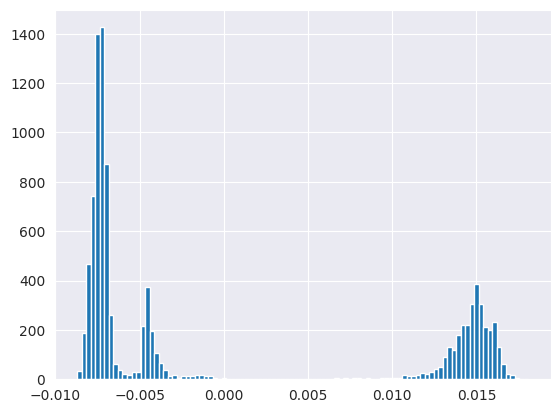

In [11]:
from cellflow.preprocessing._premetric import *
import jax.numpy as jnp
key_array = jnp.array(pca_data)
# Build the kNN graph.
W, sigma = build_knn_graph(
    pca_data,
    k=100,
    sigma=3,
    symmetrize="max",
    remove_self=True,
)
diag = W.diagonal()

print("diagonal min:", diag.min())
print("diagonal max:", diag.max())
print("diagonal mean:", diag.mean())
print("nonzero diagonal count:", np.sum(diag != 0))
from scipy.sparse.csgraph import connected_components

n_components, labels = connected_components(W, directed=False)

print("number of connected components:", n_components)

sizes = np.bincount(labels)
print("component sizes:", np.sort(sizes)[::-1][:20])
W_no_diag = W.copy()
W_no_diag.setdiag(0)
W_no_diag.eliminate_zeros()

print("non-self weight min:", W_no_diag.data.min())
print("non-self weight median:", np.median(W_no_diag.data))
print("non-self weight max:", W_no_diag.data.max())
print("non-self nnz:", W_no_diag.nnz)
print("sigma:", sigma)
print("weight min:", W.data.min())
print("weight median:", np.median(W.data))
print("weight max:", W.data.max())

print("weight quantiles:")
print(np.quantile(W.data, [0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 1.0]))
# Compute the normalized Laplacian
L = normalized_laplacian(W)
# Calculate the first k eigenfunctions of the Laplacian
s_dim = 3
evals, evecs = compute_eigens(L, k=s_dim)
print("eigenvalues:", evals)
evals = evals[1:]
evecs = evecs[:,1:]
plt.hist(evecs[:,0], bins=100)
Psi = spectral_embedding(evals, evecs, weight_type="biharmonic")

Psi_norm = np.sum(Psi**2, axis=1)

# Precompute squared distances for two known points i and j (i.e. 0 and 1):
n = Psi.shape[0]
D = np.zeros((n, n))
D = Psi_norm[:, None] + Psi_norm[None, :] - 2 * (Psi @ Psi.T)

Check for correctness of intermediate results:

In [41]:
import numpy as np
import scipy.sparse as sp
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

def print_eigenpair_residuals(L, evals, evecs):
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla

    L_norm = spla.norm(L) if sp.issparse(L) else np.linalg.norm(L)

    for i in range(len(evals)):
        lam = evals[i]
        v = evecs[:, i]

        residual = np.linalg.norm(L @ v - lam * v)
        scale = L_norm * np.linalg.norm(v) + abs(lam) * np.linalg.norm(v) + 1e-12
        relative = residual / scale

        print(
            f"{i:02d}",
            "lambda =", lam,
            "| abs residual =", residual,
            "| rel residual =", relative,
        )

print_eigenpair_residuals(L, evals, evecs)

def check_eigenpairs(L, evals, evecs, atol_abs=1e-7, atol_rel=1e-5):
    if sp.issparse(L):
        L_norm = spla.norm(L)
    else:
        L_norm = np.linalg.norm(L)

    for i in range(len(evals)):
        lam = evals[i]
        v = evecs[:, i]

        Lv = L @ v
        residual = np.linalg.norm(Lv - lam * v)

        # Stable normalization
        scale = L_norm * np.linalg.norm(v) + abs(lam) * np.linalg.norm(v) + 1e-12
        relative = residual / scale

        print(
            i,
            "lambda:", lam,
            "abs residual:", residual,
            "relative residual:", relative,
        )

        # For near-zero eigenvalues, absolute residual is more meaningful
        if abs(lam) < 1e-8:
            assert residual < atol_abs
        else:
            assert relative < atol_rel

def assert_sparse_matrix_ok(A, name="A", symmetric=False, atol=1e-8):
    assert sp.issparse(A), f"{name} is not sparse"
    assert A.shape[0] == A.shape[1], f"{name} is not square"

    # Check stored entries
    assert np.all(np.isfinite(A.data)), f"{name} has NaN or Inf entries"
    assert np.all(A.data >= 0), f"{name} has negative entries"

    # Optional symmetry check
    if symmetric:
        diff = (A - A.T).tocoo()
        if diff.nnz > 0:
            max_asym = np.max(np.abs(diff.data))
        else:
            max_asym = 0.0

        assert max_asym < atol, f"{name} is not symmetric, max asymmetry={max_asym}"

    print(f"{name} OK")

def assert_laplacian_ok(L, name="L", atol=1e-8):
    assert sp.issparse(L), f"{name} is not sparse"
    assert L.shape[0] == L.shape[1], f"{name} is not square"

    assert np.all(np.isfinite(L.data)), f"{name} has NaN or Inf entries"

    diff = (L - L.T).tocoo()
    max_asym = np.max(np.abs(diff.data)) if diff.nnz > 0 else 0.0
    assert max_asym < atol, f"{name} is not symmetric, max asymmetry={max_asym}"

    print(f"{name} OK")

def check_spectral_pipeline(W, L, evals_raw, evecs_raw, evals, evecs, Psi, D, atol=1e-8):
    import scipy.sparse as sp

    n = W.shape[0]

    # W checks
    assert sp.issparse(W)
    assert W.shape == (n, n)
    assert np.all(np.isfinite(W.data))
    assert np.all(W.data >= 0)

    diff_W = (W - W.T).tocoo()
    max_asym_W = np.max(np.abs(diff_W.data)) if diff_W.nnz > 0 else 0.0
    assert max_asym_W < atol

    deg = np.asarray(W.sum(axis=1)).ravel()
    assert np.all(np.isfinite(deg))
    assert np.all(deg > 0)

    # L checks
    assert sp.issparse(L)
    assert L.shape == (n, n)
    assert np.all(np.isfinite(L.data))

    diff_L = (L - L.T).tocoo()
    max_asym_L = np.max(np.abs(diff_L.data)) if diff_L.nnz > 0 else 0.0
    assert max_asym_L < atol

    # Eigenvalue checks
    assert np.all(np.isfinite(evals_raw))
    assert np.all(evals_raw >= -1e-8)
    assert abs(evals_raw[0]) < 1e-6

    # Eigenpair residuals
    check_eigenpairs(L, evals_raw, evecs_raw)

    # Orthonormality
    assert np.allclose(evecs_raw.T @ evecs_raw, np.eye(len(evals_raw)), atol=1e-5)

    # After removing trivial eigenfunction
    assert evals.shape[0] == evecs.shape[1]
    assert evecs.shape[0] == n
    assert np.all(evals > 1e-10)

    # Psi checks
    assert Psi.shape == evecs.shape
    assert np.all(np.isfinite(Psi))

    # D checks
    assert D.shape == (n, n)
    assert np.all(np.isfinite(D))
    assert np.allclose(D, D.T, atol=1e-7)
    assert np.allclose(np.diag(D), 0.0, atol=1e-7)
    assert D.min() > -1e-7

    # Direct distance check
    rng = np.random.default_rng(0)
    for _ in range(100):
        i, j = rng.integers(0, n, size=2)

        direct = np.sum((Psi[i] - Psi[j]) ** 2)
        fast = D[i, j]

        assert np.allclose(direct, fast, atol=1e-7)
    print("All checks passed.")

evals_raw, evecs_raw = compute_eigens(L, k=s_dim)

evals = evals_raw[1:]
evecs = evecs_raw[:, 1:]

Psi = spectral_embedding(evals, evecs, weight_type="biharmonic")

Psi_norm = np.sum(Psi**2, axis=1)
D = Psi_norm[:, None] + Psi_norm[None, :] - 2 * (Psi @ Psi.T)
D = np.maximum(D, 0.0)

check_spectral_pipeline(
    W=W,
    L=L,
    evals_raw=evals_raw,
    evecs_raw=evecs_raw,
    evals=evals,
    evecs=evecs,
    Psi=Psi,
    D=D,
)

00 lambda = 0.00013155105263305925 | abs residual = 1.9399424857362177e-05 | rel residual = 1.9441708777414238e-07
01 lambda = 0.0021587282931460963 | abs residual = 1.5875401999642795e-05 | rel residual = 1.5909681569455746e-07
02 lambda = 0.02057650351130526 | abs residual = 1.5759541344035956e-05 | rel residual = 1.579065616990055e-07
03 lambda = 0.02534616359566721 | abs residual = 1.9620920224310898e-05 | rel residual = 1.965871925220211e-07
04 lambda = 0.07636985568088278 | abs residual = 3.4673442234961546e-05 | rel residual = 3.472248860245557e-07
05 lambda = 0.09201610928661653 | abs residual = 3.208250599510922e-05 | rel residual = 3.2122854292077927e-07
06 lambda = 0.12196976412958287 | abs residual = 2.782762701205653e-05 | rel residual = 2.7854270330875877e-07
07 lambda = 0.1585143357171067 | abs residual = 6.559554394784358e-05 | rel residual = 6.563433907637479e-07
08 lambda = 0.1646151041866328 | abs residual = 8.909060372183297e-05 | rel residual = 8.913785320750589e-0

AssertionError: 

Having computed D, we can use the saved distances to approximate the spectral embeddings of unseen points by streaming: We interpolate between the k nearest neighbors using gaussian kernel weighting.

In [12]:
cf.prepare_validation_data(
    adata_test,
    name="test",
    n_conditions_on_log_iteration=None,
    n_conditions_on_train_end=None,
)

[########################################] | 100% Completed | 101.98 ms
[########################################] | 100% Completed | 102.81 ms
[########################################] | 100% Completed | 102.22 ms


In [13]:
unseen_pca = cf.validation_data["test"].cell_data

new_point = unseen_pca[0,:]

In [14]:
nystroem = SpectralNystroem(pca_data, evecs, evals, s_dim, psi=Psi, x_to_id=key_array)
new_emb = nystroem.embed_point(new_point)

There is still some normalization to do. The distances between the points are rather big. The interpolation between the points does not work yet.

## Prepare the CellFlow model

In [15]:
layers_before_pool = {
    "cytokine_treatment": {"layer_type": "mlp", "dims": [1024, 1024], "dropout_rate": 0.5},
    "donor": {"layer_type": "mlp", "dims": [256, 256], "dropout_rate": 0.0},
}

layers_after_pool = {
    "layer_type": "mlp", "dims": [1024, 1024], "dropout_rate": 0.0,
}

In [16]:
match_fn = functools.partial(match_linear, epsilon=0.5, tau_a=1.0, tau_b=1.0)

In [17]:
cf.prepare_model(
    condition_mode="deterministic",
    regularization=0.0,
    pooling="attention_token",
    pooling_kwargs={},
    layers_before_pool=layers_before_pool,
    layers_after_pool=layers_after_pool,
    condition_embedding_dim=256,
    cond_output_dropout=0.9,
    condition_encoder_kwargs={},
    pool_sample_covariates=True,
    time_freqs=1024,
    time_encoder_dims=[1024, 1024, 1024],
    time_encoder_dropout=0.0,
    hidden_dims=[2048, 2048, 2048],
    hidden_dropout=0.0,
    conditioning="concatenation",
    decoder_dims=[4096, 4096, 4096],
    vf_act_fn=nn.silu,
    vf_kwargs=None,
    probability_path={"constant_noise": 0.5},
    match_fn=match_fn,
    optimizer=optax.MultiSteps(optax.adam(5e-5), 20),
    solver_kwargs={},
    layer_norm_before_concatenation=False,
    linear_projection_before_concatenation=False,
    nystroem = nystroem
)

In [18]:
metrics_callback = cellflow.training.Metrics(metrics=["r_squared", "mmd", "e_distance"])
decoded_metrics_callback = cellflow.training.PCADecodedMetrics(ref_adata=adata_train, metrics=["r_squared"])
wandb_callback = cellflow.training.WandbLogger(project="cellflow_tutorials", out_dir="~", config={"name": "100m_pbmc"})

# we don't pass the wandb_callback as it requires a user-specific account, but recommend setting it up
callbacks = [metrics_callback, decoded_metrics_callback]

In [ ]:
cf.train(
        num_iterations=1,
        batch_size=2,
        callbacks=callbacks,
        valid_freq=20_000,
    )

  0%|          | 0/1 [00:00<?, ?it/s]

source = [[ -8.17989    26.342117 ]
 [-13.857684   -3.6048977]], xt = [[ -8.10611   26.386827]
 [-13.699525  -4.010568]], target = [[ -6.7373614  23.320621 ]
 [-11.215341   -4.819987 ]], t = [[0.09083593]
 [0.362208  ]]


100%|██████████| 1/1 [00:15<00:00, 16.00s/it]


In [ ]:
plt.plot()

In [20]:
cf.trainer.training_logs.keys()

dict_keys(['loss', 'test_r_squared_mean', 'test_mmd_mean', 'test_e_distance_mean', 'pca_decoded_test_r_squared_mean'])

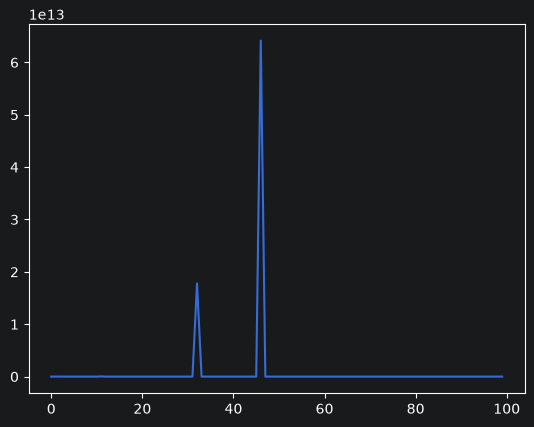

In [22]:
loss = cf.trainer.training_logs["loss"]
plt.plot(loss)

In [21]:
e_distances_train = cf.trainer.training_logs["train_e_distance_mean"]
e_distances_test = cf.trainer.training_logs["test_e_distance_mean"]
r_squared_test   = cf.trainer.training_logs["pca_decoded_test_r_squared_mean"]

iterations_train = np.arange(len(e_distances_train))
iterations_test  = np.arange(len(e_distances_test))
iterations_r2    = np.arange(len(r_squared_test))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].plot(iterations_train, e_distances_train, linestyle='-', color='blue', label='Energy distance training data')
axes[0].set_xlabel('Validation Iteration')
axes[0].set_ylabel('Energy distance')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(iterations_test, e_distances_test, linestyle='-', color='red', label='Energy distance test data')
axes[1].set_xlabel('Validation iteration')
axes[1].set_ylabel('Energy distance')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(iterations_r2, r_squared_test, linestyle='-', color='green', label='Mean R squared on test data')
axes[2].set_xlabel('Validation iteration')
axes[2].set_ylabel('R squared')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

KeyError: 'train_e_distance_mean'